# DFA

In [ ]:
import pandas as pd
import os
from scipy.interpolate import PchipInterpolator
import numpy as np
from scipy.stats import spearmanr
import piecewise_regression
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from tqdm import tqdm
import copy
import matplotlib.pyplot as plt
import fathon
from fathon import fathonUtils as fu


In [34]:
#dataframe datos de compositores 
def extraer_dataset_musica():

    datos_composers = {}
    carpeta = r'D:\La formula secreta de la cangreburger\Documentos\uaem\octavo semestre\Tesis\Sequences\labels'
    archivos_en_carpeta = os.listdir(carpeta)
    index0 = 0
    indice = 0

    for archivo in archivos_en_carpeta:
        ruta_completa = os.path.join(carpeta, archivo)
        serie = pd.read_csv(ruta_completa, header = None)
        composer = archivo.split('-')[1].capitalize() # nombre compositor
        datos_composers[composer] = {} #genero bibio para composer
        datos_composers[composer]['Birth_year'] = archivo.split('-')[0] #año de nacimiento
        index1 = serie.iloc[0, 0].split('\t')[0] #el # del primer serie del composer
        index2 = int(serie.iloc[len(serie)-3, 0].split('\t')[0]) - index0 # # Piezas
        index0 = index2 + index0 # numero total de piezas anteriores
        datos_composers[composer]['# Piezas'] = index2 # Piezas
        datos_composers[composer]['Indice'] = indice
        indice += 1

    composers = {}
    M = 0
    carpeta = r'D:\La formula secreta de la cangreburger\Documentos\uaem\octavo semestre\Tesis\Sequences\Series'
    archivos_en_carpeta = os.listdir(carpeta)

    for archivo in archivos_en_carpeta:
        ruta_completa = os.path.join(carpeta, archivo)
        serie = pd.read_csv(ruta_completa)
        # escoge una serie
        composer = archivo.split('-')[1].capitalize() # nombre compositor
        composers[composer] = {}

        for pieza in range( datos_composers[composer]['# Piezas'] ):
            N = serie.iloc[0, 0].split('\t')[1] # # de elementos por pieza
            M = int(N) + M
            index_n1 = 0 
            index_n2 = int(N)+2 
            serie_n = serie[index_n1 + 2:index_n2].reset_index(drop=True) # resetear index
            serie = serie[index_n2 +1:] # recortar serie Original
            serie_n.index += 1 # que index empiece desde 1
            num_serie_T = serie.columns[0]  # numero de serie de todo el dataset
            num_serie = pieza + 1
            composers[composer]['Serie_'+str(num_serie)] = serie_n.squeeze().to_numpy().astype(float) # agregamos pieza al dicc composer con key como # serie

    ###
    ###

    composers_depurado = copy.deepcopy(composers)
    datos_composers_depurado = copy.deepcopy(datos_composers)

    for i,composer in enumerate(composers.keys()):
        d = 0
        for pieza in composers[composer].keys():
            if len(composers[composer][pieza])//2 < 400:
                del composers_depurado[composer][pieza]
                d = d + 1
        datos_composers_depurado[composer]['# Piezas'] = datos_composers[composer]['# Piezas'] - d


    # 40 promedio de numero de piezas por compositor
    composers_depurado_v2 = copy.deepcopy(composers_depurado)
    composers_depurado_v2_keychange = copy.deepcopy(composers_depurado_v2)
    datos_composers_depurado_v2 = copy.deepcopy(datos_composers_depurado)

    for composer in composers.keys():
        if datos_composers_depurado[composer]['# Piezas'] < 30:
            del composers_depurado_v2[composer]
            del datos_composers_depurado_v2[composer]
        
    for i,composer in enumerate(composers_depurado_v2.keys()):
        datos_composers_depurado_v2[composer]['Indice'] = i 

    for composer in composers_depurado_v2.keys():
        for i,serie in enumerate(composers_depurado_v2[composer].keys()):
            composers_depurado_v2_keychange[composer]['Serie_' + str(i+1)] = composers_depurado_v2_keychange[composer].pop(serie)

    print(" # de compositores restantes: ", len(composers_depurado_v2))

    return composers_depurado_v2, datos_composers_depurado_v2

composers, datos_composers = extraer_dataset_musica()

 # de compositores restantes:  19


In [27]:
def DFA(time_series, binlog=True):
    # Convertir la serie a un formato compatible con Fathon
    my_data = fu.toAggregated(time_series)
    data_length = len(my_data)

    # Definir tamaños de ventana
    winSizes = fu.linRangeByStep(20, min(500, data_length // 4))
    revSeg = False
    polOrd = 2

    # Crear el objeto DFA y calcular las fluctuaciones
    pydfa = fathon.DFA(my_data)
    n, F = pydfa.computeFlucVec(winSizes, revSeg=revSeg, polOrd=polOrd)

    if not binlog:
        return n, F
    else:
        # Aplicar log-binning
        log_bins = np.logspace(np.log10(min(n)), np.log10(max(n)), num=15)
        binned_F = []
        binned_n = []
        for i in range(len(log_bins) - 1):
            mask = (n >= log_bins[i]) & (n < log_bins[i + 1])
            if np.any(mask):
                binned_n.append(np.mean(n[mask]))
                binned_F.append(np.mean(F[mask]))
        return np.array(binned_n), np.array(binned_F)

In [17]:
def decompose_series(increment_series):
    """Descompone la serie de incrementos en magnitudes y signos, y resta las medias."""
    magnitude_series = np.abs(increment_series)
    sign_series = np.sign(increment_series)
    
    # Restar las medias
    magnitude_series -= np.mean(magnitude_series)
    sign_series -= np.mean(sign_series)
    
    return magnitude_series, sign_series


def mdfa(time_series, binlog):
    """
    Implementación del MDFA siguiendo los pasos especificados.
    :param time_series: Serie temporal (numpy array).
    :param scale_range: Rango de tamaños de ventana para el análisis de escala.
    :return: Exponentes de escala para la serie de magnitudes y signos.
    """
    # Paso 1: Calcular la serie de incrementos
    increment_series = np.diff(time_series)
    
    # Paso 2: Descomponer la serie de incrementos en magnitud y signo, restar medias
    magnitude_series, sign_series = decompose_series(increment_series)
    
    # Paso 3: Aplicar DFA a ambas series 
    n_mag, F_mag = DFA(magnitude_series,binlog)
    # alpha_sign = DFA(sign_series)

    
    return n_mag, F_mag

In [11]:
"""iaaft - Iterative amplitude adjusted Fourier transform surrogates
        #! /usr/bin/env python3
        This module implements the IAAFT method [1] to generate time series
        surrogates (i.e. randomized copies of the original time series) which
        ensures that each randomised copy preserves the power spectrum of the
        original time series.

[1] Venema, V., Ament, F. & Simmer, C. A stochastic iterative amplitude
    adjusted Fourier Transform algorithm with improved accuracy (2006), Nonlin.
    Proc. Geophys. 13, pp. 321--328
    https://doi.org/10.5194/npg-13-321-2006

"""
# Created: Tue Jun 22, 2021  09:44am
# Last modified: Tue Jun 22, 2021  12:39pm
#
# Copyright (C) 2021  Bedartha Goswami <bedartha.goswami@uni-tuebingen.de> This
# program is free software: you can redistribute it and/or modify it under the
# terms of the GNU Affero General Public License as published by the Free
# Software Foundation, either version 3 of the License, or (at your option) any
# later version.

# This program is distributed in the hope that it will be useful,
# but WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
# GNU Affero General Public License for more details.

# You should have received a copy of the GNU Affero General Public License
# along with this program.  If not, see <https://www.gnu.org/licenses/>.
# -----------------------------------------------------------------------------


import numpy as np
from tqdm import tqdm


def iaaft(x, ns, tol_pc=5., verbose=True, maxiter=1E6, sorttype="quicksort"):
    """
    Returns iAAFT surrogates of given time series.

    Parameter
    ---------
    x : numpy.ndarray, with shape (N,)
        Input time series for which IAAFT surrogates are to be estimated.
    ns : int
        Number of surrogates to be generated.
    tol_pc : float
        Tolerance (in percent) level which decides the extent to which the
        difference in the power spectrum of the surrogates to the original
        power spectrum is allowed (default = 5).
    verbose : bool
        Show progress bar (default = `True`).
    maxiter : int
        Maximum number of iterations before which the algorithm should
        converge. If the algorithm does not converge until this iteration
        number is reached, the while loop breaks.
    sorttype : string
        Type of sorting algorithm to be used when the amplitudes of the newly
        generated surrogate are to be adjusted to the original data. This
        argument is passed on to `numpy.argsort`. Options include: 'quicksort',
        'mergesort', 'heapsort', 'stable'. See `numpy.argsort` for further
        information. Note that although quick sort can be a bit faster than 
        merge sort or heap sort, it can, depending on the data, have worse case
        spends that are much slower.

    Returns
    -------
    xs : numpy.ndarray, with shape (ns, N)
        Array containing the IAAFT surrogates of `x` such that each row of `xs`
        is an individual surrogate time series.

    See Also
    --------
    numpy.argsort

    """
    # as per the steps given in Lancaster et al., Phys. Rep (2018)
    nx = x.shape[0]
    xs = np.zeros((ns, nx))
    maxiter = 10000
    ii = np.arange(nx)

    # get the fft of the original array
    x_amp = np.abs(np.fft.fft(x))
    x_srt = np.sort(x)
    r_orig = np.argsort(x)

    # loop over surrogate number
    pb_fmt = "{desc:<5.5}{percentage:3.0f}%|{bar:30}{r_bar}"
    pb_desc = "Estimating IAAFT surrogates ..."
    for k in tqdm(range(ns), bar_format=pb_fmt, desc=pb_desc,
                  disable=not verbose):

        # 1) Generate random shuffle of the data
        count = 0
        r_prev = np.random.permutation(ii)
        r_curr = r_orig
        z_n = x[r_prev]
        percent_unequal = 100.

        # core iterative loop
        while (percent_unequal > tol_pc) and (count < maxiter):
            r_prev = r_curr

            # 2) FFT current iteration yk, and then invert it but while
            # replacing the amplitudes with the original amplitudes but
            # keeping the angles from the FFT-ed version of the random
            y_prev = z_n
            fft_prev = np.fft.fft(y_prev)
            phi_prev = np.angle(fft_prev)
            e_i_phi = np.exp(phi_prev * 1j)
            z_n = np.fft.ifft(x_amp * e_i_phi)

            # 3) rescale zk to the original distribution of x
            r_curr = np.argsort(z_n, kind=sorttype)
            z_n[r_curr] = x_srt.copy()
            percent_unequal = ((r_curr != r_prev).sum() * 100.) / nx

            # 4) repeat until number of unequal entries between r_curr and 
            # r_prev is less than tol_pc percent
            count += 1

        if count >= (maxiter - 1):
            print("maximum number of iterations reached!")

        xs[k] = np.real(z_n)

    return xs



In [12]:
def ajuste_polinomial(x, y, grado):
    """
    Ajusta un polinomio de grado especificado a los datos y grafica el ajuste.
    
    :param x: Array de valores x de los datos.
    :param y: Array de valores y de los datos.
    :param grado: Grado del polinomio a ajustar.
    :return: Coeficientes del polinomio ajustado.
    """
    # Ajustar el polinomio usando np.polyfit
    coeficientes = np.polyfit(x, y, grado)
    
    # Crear un polinomio a partir de los coeficientes ajustados
    polinomio = np.poly1d(coeficientes)
    
    # Evaluar el polinomio ajustado en los puntos x
    y_ajustado = polinomio(x)
    
    # Retornar los coeficientes del polinomio
    return y_ajustado, coeficientes

def evaluar_derivada(coeficientes, x_valor):
    """
    Calcula la primera derivada de un polinomio y la evalúa en un valor arbitrario.
    
    :param coeficientes: Coeficientes del polinomio (array).
    :param x_valor: Valor en el que se desea evaluar la derivada.
    :return: Valor de la primera derivada del polinomio evaluada en x_valor.
    """
    # Crear el polinomio a partir de los coeficientes
    polinomio = np.poly1d(coeficientes)
    
    # Calcular la primera derivada del polinomio
    derivada = np.polyder(polinomio)
    
    # Evaluar la derivada en el valor especificado
    derivada_evaluada = derivada(x_valor)
    return np.array(derivada_evaluada)

In [13]:
def ajuste_polinomial_auto(x, y, grado_max=10, criterio="mse"):
    """
    Determina el grado óptimo del polinomio que mejor se ajusta a los datos
    y devuelve el polinomio ajustado junto con sus coeficientes.
    
    :param x: Array de valores x de los datos.
    :param y: Array de valores y de los datos.
    :param grado_max: Máximo grado de polinomio a evaluar.
    :param criterio: Criterio para seleccionar el grado óptimo ("mse", "aic" o "bic").
    :return: y_ajustado (valores del polinomio en los puntos x) y coeficientes del polinomio ajustado.
    """
    mejor_grado = 0
    mejor_metrica = np.inf
    mejor_coeficientes = None
    
    n = len(x)  # Número de datos
    
    for grado in range(1, grado_max + 1):
        # Ajustar el polinomio
        coeficientes = np.polyfit(x, y, grado)
        polinomio = np.poly1d(coeficientes)
        y_pred = polinomio(x)
        
        # Calcular el error cuadrático medio
        mse = np.mean((y - y_pred) ** 2)
        
        if criterio == "mse":
            metrica = mse
        elif criterio == "aic":
            # AIC = n * log(mse) + 2 * (p + 1), donde p es el grado
            metrica = n * np.log(mse) + 2 * (grado + 1)
        elif criterio == "bic":
            # BIC = n * log(mse) + log(n) * (p + 1)
            metrica = n * np.log(mse) + np.log(n) * (grado + 1)
        else:
            raise ValueError("Criterio no válido. Usa 'mse', 'aic' o 'bic'.")
        
        # Verificar si este grado es mejor
        if metrica < mejor_metrica:
            mejor_metrica = metrica
            mejor_grado = grado
            mejor_coeficientes = coeficientes
    
    # Crear el polinomio con los coeficientes del mejor ajuste
    mejor_polinomio = np.poly1d(mejor_coeficientes)
    y_ajustado = mejor_polinomio(x)
    
    return y_ajustado, mejor_coeficientes, mejor_grado


In [ ]:
def main(time_series, method, binlog=False, grado_polinomio=4, N_surrogates=100, graficar=True):
    H = []

    # CALCULAR MDFA O DFA
    if method == 'MDFA':
        n, F = mdfa(time_series,binlog=binlog)
    elif method == 'DFA':
        n, F = DFA(time_series, binlog=binlog)
    else:
        raise ValueError("El método debe ser 'MDFA' o 'DFA'")

    # GENERAR SURROGADOS
    flucts_surrogates = []
    surrogates = iaaft(time_series, N_surrogates)
    for i in range(N_surrogates):
        if method == 'MDFA':
            n_surr, flucts_surr = mdfa(surrogates[i, :],binlog=binlog)
        elif method == 'DFA':
            n_surr, flucts_surr = DFA(surrogates[i, :], binlog=binlog)
        flucts_surrogates.append(np.log10(flucts_surr))
    flucts_surrogates = np.vstack(flucts_surrogates)

    # REGRESIÓN SEGMENTADA
    n_breakpoints = 1
    while True:
        pw_fit = piecewise_regression.Fit(np.log10(n), np.log10(F), n_breakpoints=n_breakpoints)
        pw_results = pw_fit.get_results()
        pw_estimates = pw_results["estimates"]

        if pw_results['converged']:
            print('converged')
            break
        elif n_breakpoints != 1:
            n_breakpoints -= 1
        else:
            break
    
    if not pw_results['converged']:
        print('Not converged')
        return np.nan

    for value in pw_estimates:
        if 'alpha' in value:
            H.append(pw_estimates[value]['estimate'])

    if graficar:
        pw_fit.plot_data(color="red", s=1, label='log(F(s))')
        pw_fit.plot_breakpoints()

    lower_bound = np.min(flucts_surrogates, axis=0)
    upper_bound = np.max(flucts_surrogates, axis=0)
    if graficar:
        plt.fill_between(np.log10(n_surr), lower_bound, upper_bound, color='blue', alpha=0.2, label='Surrogates')

    # AJUSTE POLINOMIAL Y DERIVADAS
    if not binlog:
        # === Ajuste por segmentos ===
        past_idx = 0
        derivadas = np.array([])
        y_ajustados = np.array([])

        for i in range(n_breakpoints):
            pts = pw_estimates[f'breakpoint{i + 1}']['estimate']
            idx_closest = int(np.argmin(np.abs(np.log10(n) - pts)))
            y_ajustado, coeficientes = ajuste_polinomial(np.log10(n)[past_idx:idx_closest + 1], np.log10(F)[past_idx:idx_closest + 1], grado=grado_polinomio)
            derivadas = np.concatenate((derivadas, evaluar_derivada(coeficientes, np.log10(n)[past_idx:idx_closest + 1])))
            y_ajustados = np.concatenate((y_ajustados, y_ajustado))
            past_idx = idx_closest + 1

        y_ajustado, coeficientes = ajuste_polinomial(np.log10(n)[past_idx:], np.log10(F)[past_idx:], grado=grado_polinomio)
        derivadas = np.concatenate((derivadas, evaluar_derivada(coeficientes, np.log10(n)[past_idx:])))
        y_ajustados = np.concatenate((y_ajustados, y_ajustado))

        if graficar:
            plt.plot(np.log10(n), y_ajustados, color='green', label=f'Ajuste polinomial (grado {grado_polinomio})')

        derivadas_surr = np.zeros([N_surrogates, len(np.log10(n_surr))])
        for surr_index in range(N_surrogates):
            past_idx_surr = 0
            for i in range(n_breakpoints):
                pts_surr = pw_estimates[f'breakpoint{i + 1}']['estimate']
                idx_closest_surr = np.argmin(np.abs(np.log10(n_surr) - pts_surr))
                _, coef_surr = ajuste_polinomial(
                    np.log10(n_surr)[past_idx_surr:idx_closest_surr + 1],
                    flucts_surrogates[surr_index, past_idx_surr:idx_closest_surr + 1],
                    grado=grado_polinomio
                )
                derivadas_surr[surr_index, past_idx_surr:idx_closest_surr + 1] = evaluar_derivada(
                    coef_surr, np.log10(n_surr)[past_idx_surr:idx_closest_surr + 1]
                )
                past_idx_surr = idx_closest_surr + 1

            _, coef_surr = ajuste_polinomial(
                np.log10(n_surr)[past_idx_surr:], 
                flucts_surrogates[surr_index, past_idx_surr:], 
                grado=grado_polinomio
            )
            derivadas_surr[surr_index, past_idx_surr:] = evaluar_derivada(
                coef_surr, np.log10(n_surr)[past_idx_surr:]
            )

    else:
        # === Ajuste global ===
        y_ajustado, coeficientes = ajuste_polinomial(np.log10(n), np.log10(F), grado=grado_polinomio)
        derivadas = evaluar_derivada(coeficientes, np.log10(n))

        if graficar:
            plt.plot(np.log10(n), y_ajustado, color='green', label=f'Ajuste polinomial (grado {grado_polinomio})')

        derivadas_surr = np.zeros([N_surrogates, len(np.log10(n_surr))])
        for surr_index in range(N_surrogates):
            _, coef_surr = ajuste_polinomial(np.log10(n_surr), flucts_surrogates[surr_index], grado=grado_polinomio)
            derivadas_surr[surr_index, :] = evaluar_derivada(coef_surr, np.log10(n_surr))

    derivadas_surr_mean = np.mean(derivadas_surr, axis=0)
    derivadas_surr_std = np.std(derivadas_surr, axis=0)

    if graficar:
        plt.xlabel('log(s)', fontsize=14)
        plt.ylabel('log(F(s))', fontsize=14)
        plt.title('DFA', fontsize=14)
        plt.legend(loc=0, fontsize=7)
        plt.show()
        plt.close()

        plt.figure()
        plt.plot(np.log10(n), derivadas, color='green', ls='', marker='.', label='Derivadas de la serie original')
        plt.fill_between(
            np.log10(n_surr),
            derivadas_surr_mean - derivadas_surr_std,
            derivadas_surr_mean + derivadas_surr_std,
            color='blue', alpha=0.2, label='Surrogates: Mean ± Std'
        )
        plt.xlabel('log(s)', fontsize=14)
        plt.ylabel("Derivada del polinomio", fontsize=14)
        plt.title("Derivadas del ajuste polinomial vs log(s)", fontsize=14)
        plt.legend(loc=0, fontsize=10)
        plt.show()

    # ÍNDICE DE NO LINEALIDAD
    xi = np.sum(np.abs(derivadas - derivadas_surr_mean) / derivadas_surr_std)
    xi_index = xi / len(derivadas)
    return xi_index

In [60]:
plt.style.use('ggplot')
%matplotlib inline

dict_keys(['Serie_1', 'Serie_3', 'Serie_4', 'Serie_5', 'Serie_6', 'Serie_7', 'Serie_10', 'Serie_11', 'Serie_12', 'Serie_15', 'Serie_16', 'Serie_19', 'Serie_22', 'Serie_25', 'Serie_30', 'Serie_62', 'Serie_63', 'Serie_64', 'Serie_65', 'Serie_66', 'Serie_67', 'Serie_68', 'Serie_69', 'Serie_70', 'Serie_71', 'Serie_72', 'Serie_73', 'Serie_74', 'Serie_75', 'Serie_77', 'Serie_80', 'Serie_82', 'Serie_83', 'Serie_84', 'Serie_85', 'Serie_87', 'Serie_91', 'Serie_92', 'Serie_93', 'Serie_94', 'Serie_95', 'Serie_96', 'Serie_101', 'Serie_103', 'Serie_104', 'Serie_105', 'Serie_106', 'Serie_107', 'Serie_108', 'Serie_114', 'Serie_115', 'Serie_170', 'Serie_171', 'Serie_172', 'Serie_173', 'Serie_182', 'Serie_184', 'Serie_185', 'Serie_186', 'Serie_187', 'Serie_188', 'Serie_189', 'Serie_190', 'Serie_191', 'Serie_192', 'Serie_193', 'Serie_194', 'Serie_195', 'Serie_196', 'Serie_197', 'Serie_198', 'Serie_199', 'Serie_200', 'Serie_201', 'Serie_202', 'Serie_203', 'Serie_204', 'Serie_205', 'Serie_208', 'Serie_209

Estim100%|██████████████████████████████| 100/100 [00:00<00:00, 307.68it/s]


converged


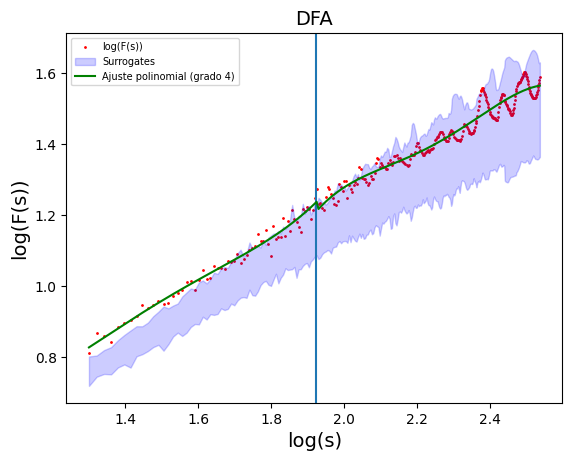

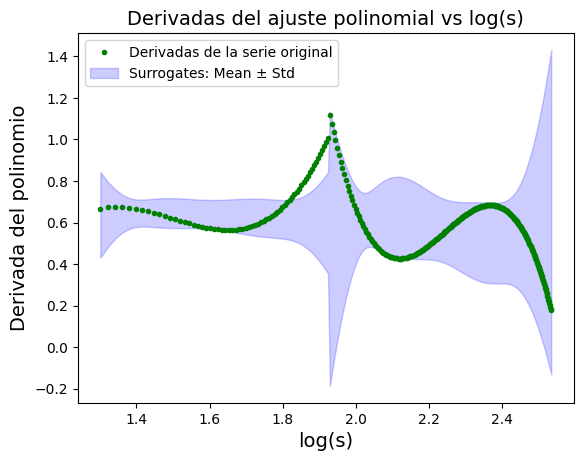

0.6466262029322333 Serie_18 Byrd


Estim100%|██████████████████████████████| 100/100 [00:00<00:00, 163.38it/s]


TypeError: 'NoneType' object is not iterable

In [ ]:
print(composers['Beethoven'].keys())
for composer, serie in zip(['Beethoven','Beethoven','Schubert','Schumann','Brahms'],['Serie_443','Serie_447','Serie_242', 'Serie_13','Serie_111']):
    subject = composers[composer][serie]
    E = main(subject, 'DFA')
    print(E,serie,composer)

Estim100%|██████████████████████████████| 100/100 [00:00<00:00, 143.66it/s]


converged


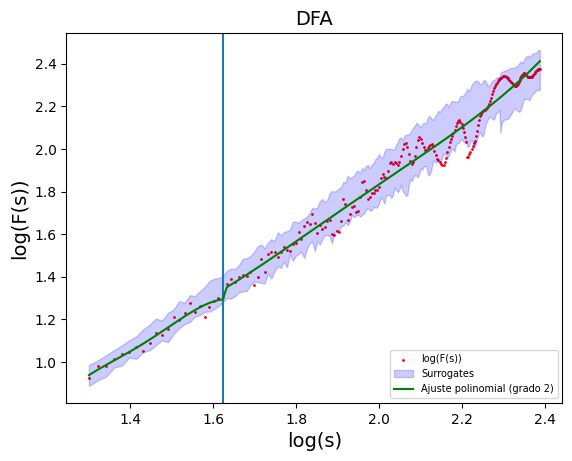

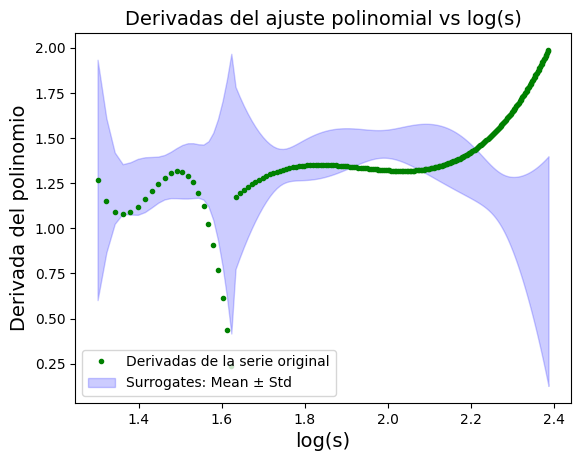

Estim100%|██████████████████████████████| 100/100 [00:00<00:00, 126.42it/s]


converged


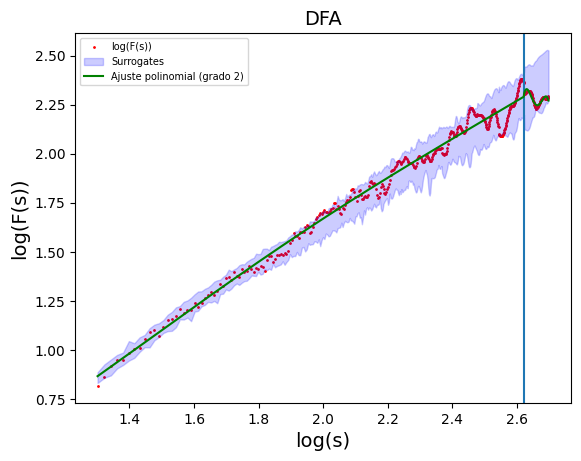

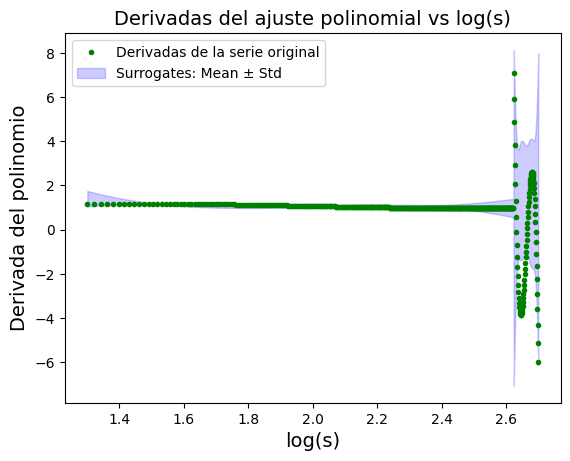

Estim100%|██████████████████████████████| 100/100 [00:00<00:00, 347.22it/s]


converged


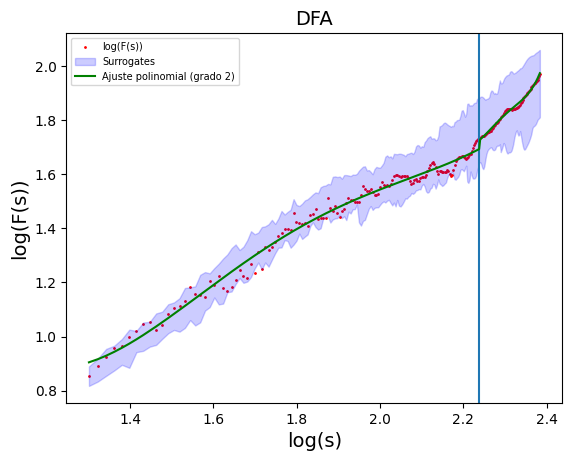

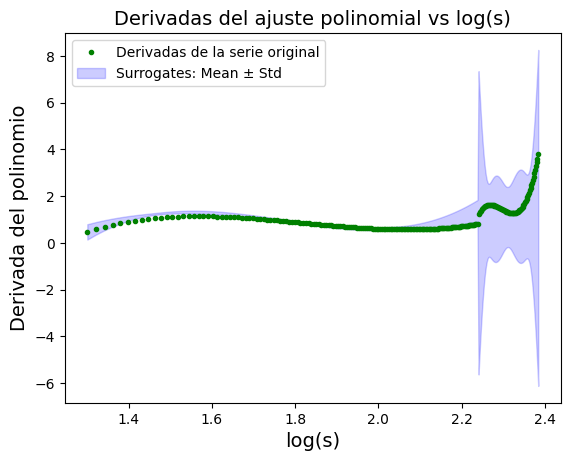

Estim100%|██████████████████████████████| 100/100 [00:00<00:00, 348.43it/s]


converged


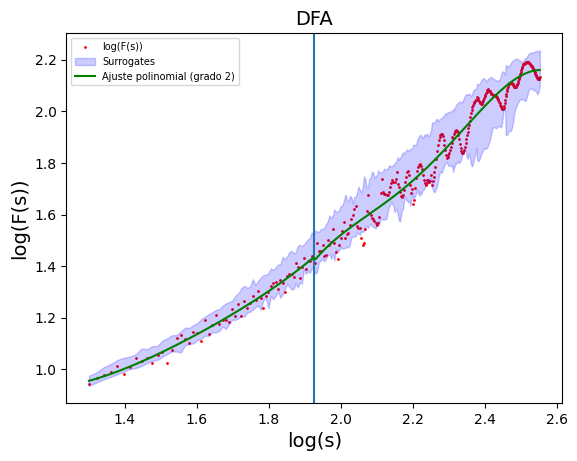

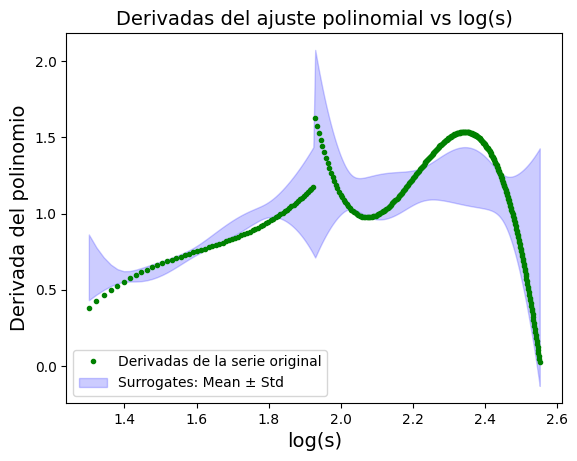

Estim100%|██████████████████████████████| 100/100 [00:00<00:00, 588.13it/s]


converged


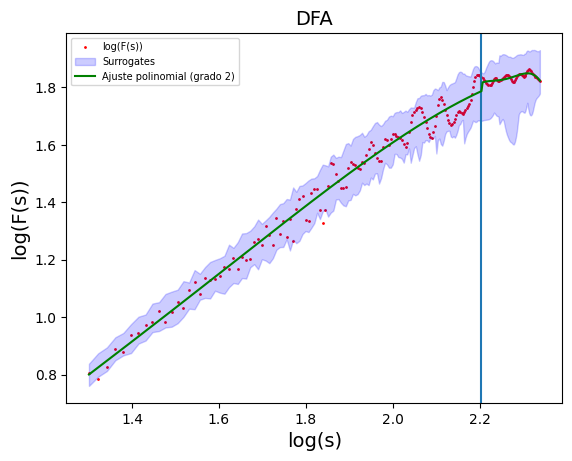

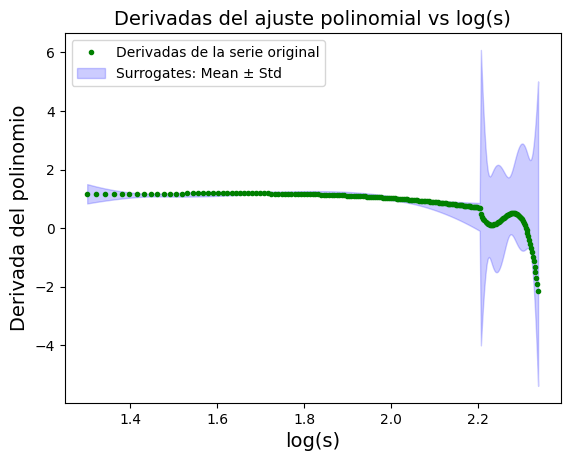

Estim100%|██████████████████████████████| 100/100 [00:00<00:00, 159.49it/s]


converged


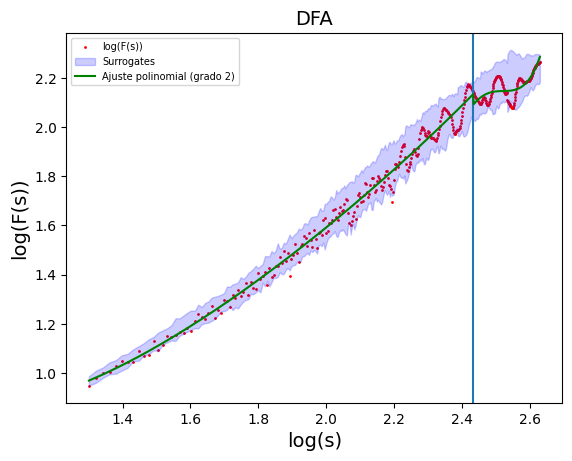

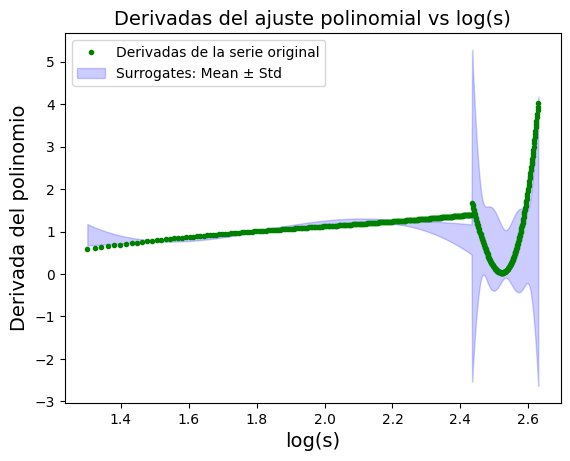

Estim100%|██████████████████████████████| 100/100 [00:00<00:00, 182.15it/s]


TypeError: 'NoneType' object is not iterable

In [ ]:
composer = 'Debussy'
xi_index = np.zeros((datos_composers[composer]['# Piezas'], 2))

for i, serie in enumerate(composers[composer].keys()): 
    # if int(serie.split('_')[1]) < 413:
    #     print(serie)
    #     continue
    subject = composers[composer][serie]
    xi_index[i,0] = int(serie.split('_')[1])
    xi_index[i,1] = main(subject, 'DFA')



In [ ]:
def porcentaje_mayores_a_uno(array):
    array = np.array(array)  # Asegurarse de que sea un array de numpy
    total = len(array)
    mayores_a_uno = np.sum(array > 1.)  # Contar números mayores a 1
    porcentaje = (mayores_a_uno / total) * 100
    return porcentaje


Ns = np.load('Ns_depurado.npy')//2
resultado = porcentaje_mayores_a_uno(xi_index[:,1])
print(f"El porcentaje de números mayores a 1 es: {resultado:.2f}%")


Correlación de Spearman: 0.04029881121277255
El porcentaje de números mayores a 1 es: 82.61%


2677 2677 2677


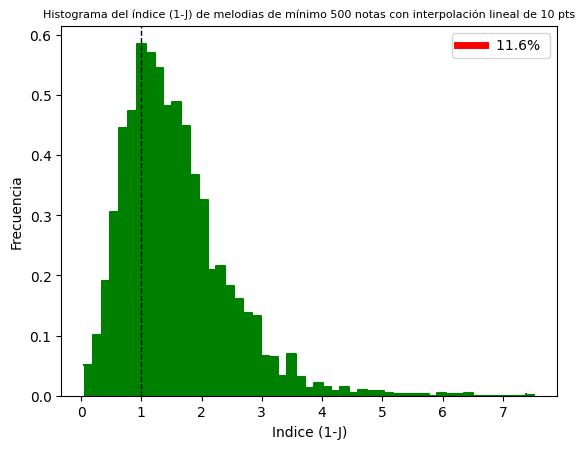

In [79]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import pickle

path = 'D:/La formula secreta de la cangreburger/Documentos/uaem/octavo semestre/Tesis'
with open(f"{path}/J_run_avg.pkl", "rb") as f:
    J_run_avg = pickle.load(f)

data_nonlineality = np.load(f'{path}/xi_index_global.npy')#(1-umbral)-0.2
# data1_flat = np.load('J_composers_lineal_global.npy')
pts_interp = 10
data1_flat = np.array([])
for composer in composers.keys():
        # array = 1-np.load('J_composers_tests/Derivadas_abs/'+ str(datos_composers[composer]['Birth_year']) + '_J_interp_' + str(composer) + '.npy')
        array = 1-np.load(f'{path}/J_hermite_sincorte_depurado/interp_'+str(pts_interp)+'/'+ str(datos_composers[composer]['Birth_year']) + '_J_interp_' + str(composer) + '_herm.npy')
        data1_flat = np.concatenate((data1_flat,array))

data2_flat = np.load(f'{path}/J_composers_hermite_global.npy')
OG_data_flat = 1-np.load(f'{path}/J_composers_global.npy')
J_run_avg = np.concatenate(J_run_avg)
data_constante = np.load(f'{path}/J_composers_interp_constant.npy')
print(len(OG_data_flat),len(data_nonlineality),len(data1_flat))

umbral = 0.019061054240866748
# umbral = 0.02905897738354482
# umbral = 0.031481763770571186
# umbral = 0.035399093872396606
# umbral = 0.041381653029154905
umbral = 0.05073303303890251 # 1 pts
# umbral = 0.0745374980780404
# Crear histogramas y obtener los valores de las barras
porcentaje = 11.6

counts_epsilon, bins_epsilon, _ = plt.hist(data_nonlineality,bins='auto', color='green', alpha=1, edgecolor='none', label=f'$\epsilon$ index',density= True)
# counts1, bins1, patches = plt.hist(data1_flat,bins=60, alpha=1,color='red', edgecolor='none', label=f'Index J {porcentaje:.1f}% (Interplineal {pts_interp} pts)', density = True)
# plt.hist(data1_flat[data1_flat < umbral],bins=5, alpha=1,color='blue', edgecolor='none',density=True)
# counts2, bins2, _ = plt.hist(data2_flat, bins=50, color='blue', alpha=1, edgecolor='none', label='Index J (InterpHermite)', density = True)
# counts3, bins3, _ = plt.hist(OG_data_flat, bins=50, color='gray',alpha=1, edgecolor='none', label='Index J (Datos Originales)',density = True)
# counts4, bins4, _ = plt.hist(J_run_avg, bins=50, color='brown', alpha=1, edgecolor='none', label='Index J (Running avg)', density = True)
# counts5, bins5, _ = plt.hist(data_constante, bins=50, color='green', alpha=1, edgecolor='none', label='Index J (Interp constante)', density = True)

# Dibujar los contornos superiores de cada histograma

plt.plot(bins_epsilon[:-1], counts_epsilon, drawstyle='steps-post', color='green')
# plt.plot(bins1[:-1], counts1, drawstyle='steps-post', alpha = 0.5)
# for i, patch in enumerate(patches):
    # if bins1[i] <= umbral:  # Comparar con el borde izquierdo del bin
        # patch.set_facecolor('blue')  # Color para bins a la izquierda
    # else:
        # patch.set_facecolor('red') 
# plt.plot(bins2[:-1], counts2, drawstyle='steps-post', color='blue',alpha = 0.5)
# plt.plot(bins3[:-1], counts3, drawstyle='steps-post', color='white',alpha = 0.3)
# plt.plot(bins4[:-1], counts4, drawstyle='steps-post', color='brown',alpha = 0.5)
# plt.plot(bins5[:-1], counts5, drawstyle='steps-post', color='green',alpha = 0.5)
plt.axvline(x=np.mean([1]), color='black', linestyle='--', linewidth=1, label='Umbral')

# Personalizar la gráfica
plt.xlabel(r'Indice (1-J)')
# plt.xlabel(r'Indice de no linealidad $\xi$')
plt.ylabel('Frecuencia')
# plt.title(r'Histograma del índice (1-J) de melodias de mínimo 500 notas (sin interpolación)', fontsize=8)
plt.title(r'Histograma del índice (1-J) de melodias de mínimo 500 notas con interpolación lineal de'+f' {pts_interp} pts', fontsize=8)
custom_legend = [
    # Line2D([0], [0], color='black', linestyle='--', label='Umbral'),
    Line2D([0], [0], color='red', lw=5,label=f'{porcentaje:.1f}% '),
]
plt.legend(handles=custom_legend)
plt.show()